# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

sns.set(style="whitegrid")

# 2. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/Delhi_AQIBulletins.csv')

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Sort
df = df.sort_values('date')

# Keep required columns
df = df[['date', 'index value']]

# Handle missing values
df['index value'] = df['index value'].fillna(method='ffill')

# Set date as index (TIME-SERIES FORMAT)
df.set_index('date', inplace=True)

df.head()

C:\Users\gprab\AppData\Local\Temp\ipykernel_30876\1027450473.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['index value'] = df['index value'].fillna(method='ffill')


,index value
date,
2015-05-01,221
2015-05-02,238
2015-05-03,259
2015-05-04,289
2015-05-05,311


# 3. Scaling Data

In [3]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['index value']])

# 4. Create Windowed Dataset (Sliding Window)

In [4]:
def create_dataset(data, window_size=7):
    X, y = [], []
    
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    
    return np.array(X), np.array(y)

window_size = 7  # 7 days → predict next day

X, y = create_dataset(scaled_data, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3136, 7, 1)
y shape: (3136, 1)


# 5. Train-Test Split

In [5]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. Build LSTM Model

In [6]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(window_size, 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

C:\Users\gprab\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 7, 50)               │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Train Model

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0332 - val_loss: 0.0146
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0173 - val_loss: 0.0139
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0167 - val_loss: 0.0132
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0156 - val_loss: 0.0119
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0147 - val_loss: 0.0113
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0137 - val_loss: 0.0106
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0125 - val_loss: 0.0095
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0120 - val_loss: 0.0087
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0111 - val_loss: 0.0088
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0110 - val_loss: 0.0086
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0111 - val_loss: 0.0085
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.

# 8. Predictions

In [8]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Inverse transform
train_pred = scaler.inverse_transform(train_pred)
y_train_actual = scaler.inverse_transform(y_train)

test_pred = scaler.inverse_transform(test_pred)
y_test_actual = scaler.inverse_transform(y_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


# 9. Evaluation Metrics (VERY IMPORTANT FOR MARKS)

In [9]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

train_mae, train_rmse = evaluate(y_train_actual, train_pred)
test_mae, test_rmse = evaluate(y_test_actual, test_pred)

print(f"Train MAE: {train_mae:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")

print(f"Test MAE: {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train MAE: 35.29
Train RMSE: 46.88
Test MAE: 31.74
Test RMSE: 41.80


# 10. Plot Predicted vs Actual (CORE REQUIREMENT)

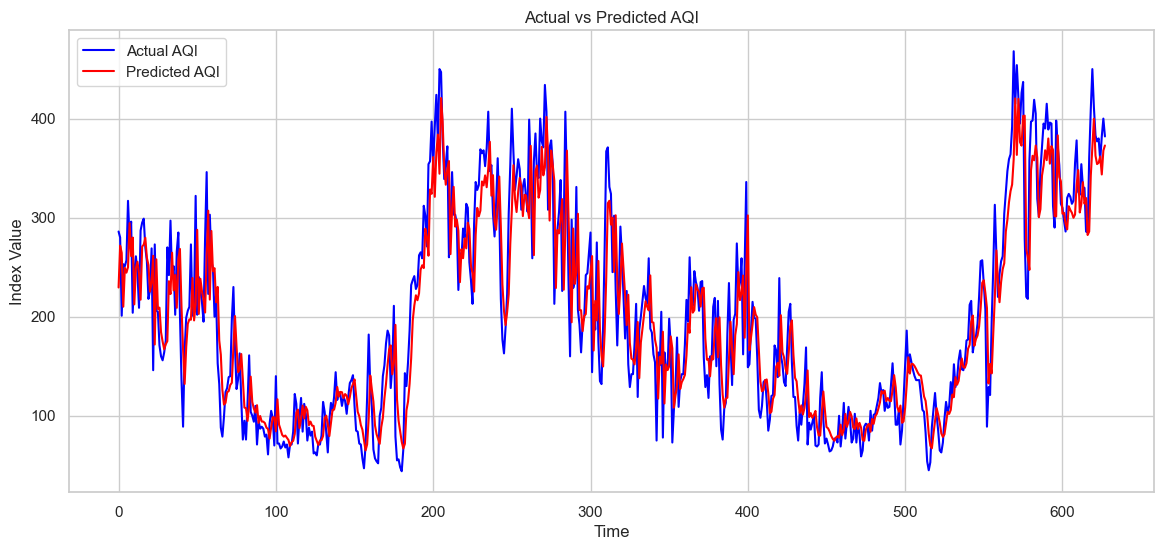

In [10]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label='Actual AQI', color='blue')
plt.plot(test_pred, label='Predicted AQI', color='red')

plt.title("Actual vs Predicted AQI")
plt.xlabel("Time")
plt.ylabel("Index Value")

plt.legend()
plt.show()

# 11. Forecast Next Day

In [11]:
last_window = scaled_data[-window_size:]
last_window = last_window.reshape(1, window_size, 1)

next_day_pred = model.predict(last_window)
next_day_pred = scaler.inverse_transform(next_day_pred)

print("Predicted AQI for next day:", next_day_pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted AQI for next day: 355.13007


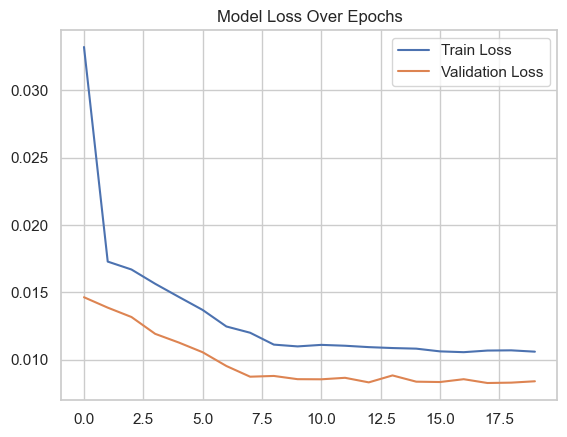

In [12]:
# Loss curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss Over Epochs")
plt.legend()
plt.show()